In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib import rcParams
import statsmodels.formula.api as smf

rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 12

chamber_list = [7, 6, 19, 20, 11, 13, 4, 8, 16, 17, 10]
chambers_ordered = {
    'amb': ['7', '6', '20', '13', '8', '17'],
    'elev': ['19', '11', '4', '16', '10']
}
xticklabels = ['TAMB', 'T0.00', 'T2.25', 'T4.50', 'T6.75', 'T9.00', 
               'T0.00CO2', 'T2.25CO2', 'T4.5CO2', 'T6.75CO2', 'T9.00CO2']

In [2]:
"""
Annual maximum LAI observation unit conversion notes: 

The PFT-level model output should be multiplied by the PFT fraction (0.36 = pima, 0.14 = lala, 0.25 = shrub) to get the plot average number. 

Also, Paul's number here is for the entire enclosure (114.8 m2), while these model results were just simulating the area within the boardwalks (66.4 m2)

So for the best comparison against model LAI, Paul's number here is multiplied by 114.8/66.4/(frac_PFT) = 4.8 for pima, 12.3 for lala, 6.9 for shrub.

When we next optimize the model, we'll use these numbers from Paul and set up the simulation to represent the whole enclosure to better match his numbers.
"""
year_list    = range(2015, 2022)
pft_list     = ['2', '3', '11']

data = pd.read_excel(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input', 
                                  'LAI Record_30Jun2021.xlsx'),
                     sheet_name = 'Pivot By Veg Type and Plot Copy', usecols = 'A:D')
data['Year'] = data['Year'].astype(int)
data['Plot'] = data['Plot'].astype(int)
data = data.set_index(['Year', 'Plot', 'Vegetation type'])

annual_lai_raw = pd.DataFrame(np.nan, 
                          columns = pd.MultiIndex.from_product([pft_list, 
                                                                chambers_ordered['amb'] + \
                                                                chambers_ordered['elev']]), 
                          index = range(2014, 2022))

for i in range(len(chamber_list)):
    for j, (pft, name) in enumerate(zip(['2','3','11'], 
                                        ['Evergreen Tree', 'Deciduous Tree', 'Shrub'])):
        for k in range(2014,2022):
            if k == 2021:
                continue
            if (k == 2020) & (pft == '11'):
                continue
            temp = float(data.loc[(k, chamber_list[i], name), 'Sum of LAI'])
            # adjust the area of the LAI to the area of the chamber
            annual_lai_raw.loc[k, (pft, str(chamber_list[i]))] = temp * 114.8 / 66.4

In [3]:
# Use linear regression to remove the pre-treatment effect
obs_paul = pd.read_excel(os.path.join(os.environ['HOME'],
    'Git', 'phenology_elm', "SPRUCE C Budget Summary 28Apr2022EXP.xlsx"),
    sheet_name="DataForPythonRead", skiprows=1,  engine="openpyxl")
obs_paul = obs_paul.loc[obs_paul["Year"] != 2020, :]
obs_paul = obs_paul.set_index(['Plot', 'Year']).sort_index()

tair = obs_paul['Mean Annual Temp. at 2 m']
eCO2 = (obs_paul['CO2'] == 500).astype(int)

annual_lai = pd.DataFrame(np.nan, 
                          columns = pd.MultiIndex.from_product([pft_list, 
                                                                chambers_ordered['amb'] + \
                                                                chambers_ordered['elev']]), 
                          index = year_list)
for pft in ['2','3','11']:

    # Create the dataset
    pretreatment = annual_lai_raw.loc[2014, pft]
    pretreatment.index = [f'P{int(p):02d}' for p in pretreatment.index]

    posttreatment = annual_lai_raw.loc[2015:, pft]
    posttreatment.columns = [f'P{int(p):02d}' for p in posttreatment.columns]
    posttreatment = posttreatment.unstack()

    X = pd.concat([tair, eCO2, posttreatment.to_frame()], axis = 1)
    X.columns = ['Tair','eCO2','Postrt']
    X['Pretrt'] = X.index.get_level_values(0).map(pretreatment)
    X.index.names = ['Plot','Year']

    df = X.dropna(how = 'any').reset_index()

    # Full model
    full_formula = ("Postrt ~ eCO2 + Tair + Year + Pretrt + eCO2:Tair + eCO2:Year")
    full_mod = smf.ols(full_formula, data=df).fit()

    # Drop insignificant terms and refit
    keepers = [
        term for term, p in full_mod.pvalues.items()
        if (term == "Intercept") or (p <= 0.05)
    ]

    print(pft, keepers)

    # No pretreatment effect, then subtract nothing
    if not ('Pretrt' in keepers):
        adjusted = X.loc[:, 'Postrt']
    else:
        # Has pretreatment effect, fit reduced model
        reduced_formula = "Postrt ~ " + " + ".join(k for k in keepers if k != "Intercept")
        results = smf.ols(reduced_formula, data=df).fit()

        #print(results.summary())

        # Subtract the pretreatment effect if significant
        # (add back the mean of the pretreatment level)
        baseline = 0
        dpretrt = X['Pretrt'].values - X['Pretrt'].mean()
        if 'Pretrt' in results.pvalues.index and results.pvalues['Pretrt'] <= 0.05:
            baseline += results.params['Pretrt'] *dpretrt
        adjusted = X['Postrt'] - baseline

    adjusted = adjusted.unstack()
    adjusted.index = [str(int(p[1:])) for p in adjusted.index]
    adjusted = adjusted.T

    annual_lai.loc[:, pft] = adjusted.loc[:, annual_lai.loc[:,pft].columns].values

2 ['Intercept', 'eCO2', 'Tair', 'Year', 'Pretrt', 'eCO2:Tair', 'eCO2:Year']
3 ['Intercept', 'Year', 'Pretrt', 'eCO2:Tair']
11 ['Intercept', 'Year']


In [4]:
# Read the modeled annual maximum TLAI
prefix_list = ['20231116', 'UQ_20231118', 'UQ_20240107', 'UQ_20240112']
name_list = ['E-OLD', 'E-OLD$_{optim}$', 'E-NU', 'E-NU$_{optim}$']
pft_names = ['Spruce', 'Tamarack', 'Shrub']
frac_list = [0.36, 0.14, 0.25]
collection_gs = {}

for prefix in prefix_list:
    temp_data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 
                                         'extract', prefix, 'analysis_ts.csv'),
                                         header = [0, 1, 2, 3], index_col = 0, parse_dates=True)
    temp_data = temp_data.loc[:, (slice(None), 'TLAI')]
    temp_data.columns = temp_data.columns.droplevel(1)

    # average hummock and hollow, resample to annual
    temp_data = temp_data.groupby(['pft', 'plot'], axis = 1
        ).apply(lambda df: df.iloc[:,0] * 0.64 + df.iloc[:,1] * 0.36)
    for p, pft in enumerate([2, 3, 11]):
        temp_data.loc[:, str(pft)] = temp_data.loc[:, str(pft)].values * frac_list[p]
    temp_data = temp_data.loc[:, ['2','3','11']]

    #filt = (temp_data.index.month >= 5) & (temp_data.index.month <= 10)
    filt = (temp_data.index.month >= 1) & (temp_data.index.month <= 12)
    # Limit to < 2021 to be consistent with Paul's data
    filt = filt & (temp_data.index.year <= 2021)
    temp_annual = temp_data.loc[filt, :].resample('1Y').max()
    temp_annual.index = temp_annual.index.year
    temp_annual.columns = temp_annual.columns.reorder_levels(['pft', 'plot'])    
    collection_gs[prefix] = temp_annual.sort_index(axis = 1)

/tmp/ipykernel_2118867/163590066.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft', 'plot'], axis = 1
/tmp/ipykernel_2118867/163590066.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft', 'plot'], axis = 1
/tmp/ipykernel_2118867/163590066.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft', 'plot'], axis = 1
/tmp/ipykernel_2118867/163590066.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft', 'plot'], axis = 1


obs 2 1.8231268126183902
sim 2 20231116 4.345445618548363
sim 2 UQ_20231118 3.978203950551273
sim 2 UQ_20240107 3.116387521675636
sim 2 UQ_20240112 2.7494956469585454
obs 3 0.5216051869515594
sim 3 20231116 0.7359367886894546
sim 3 UQ_20231118 0.762326039613091
sim 3 UQ_20240107 0.6791389669323636
sim 3 UQ_20240112 0.9200619048727272
obs 11 2.020987116506657
sim 11 20231116 1.3255443695636364
sim 11 UQ_20231118 1.4089707988363638
sim 11 UQ_20240107 1.0545763423999999
sim 11 UQ_20240112 1.5133943545454547


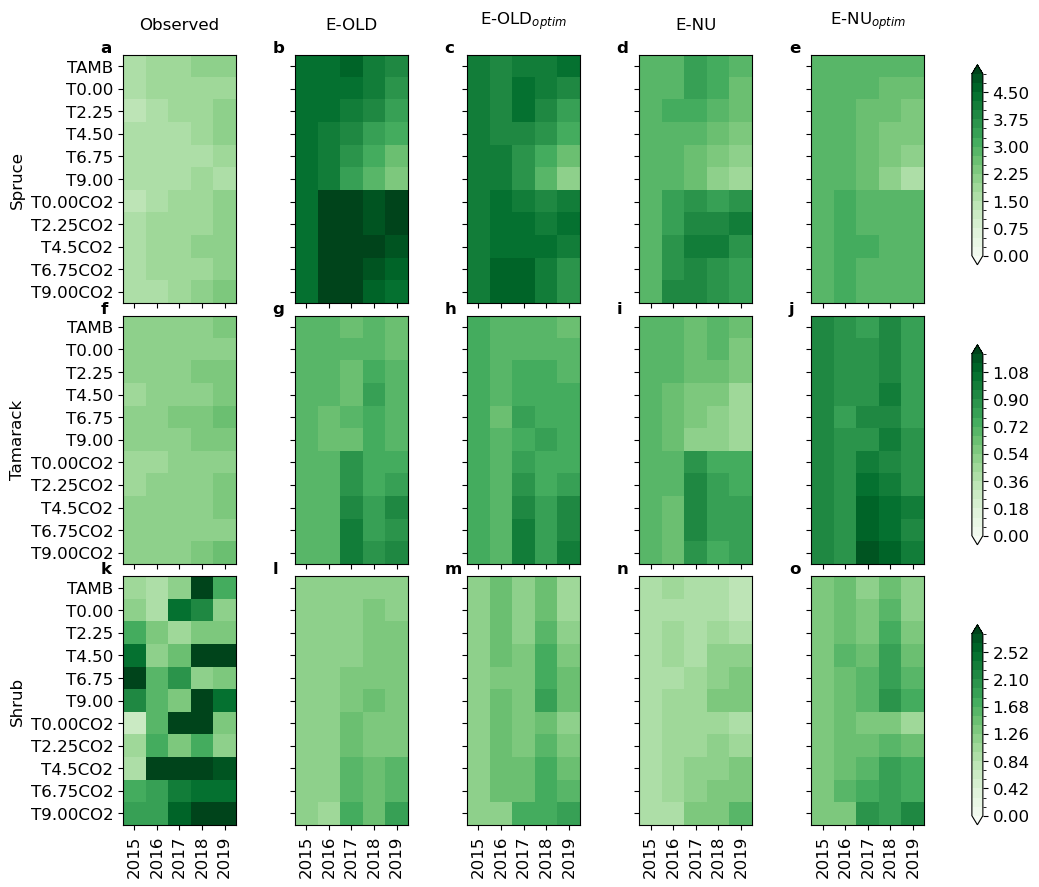

In [5]:
fig, axes = plt.subplots(3, 1 + len(prefix_list), figsize = (11, 10), sharex = True, sharey = True)
fig.subplots_adjust(hspace = 0.05, wspace = 0.05)
labs = 'abcdefghijklmnopqrstuvwxyz'
count = 0
for i, (pft,name) in enumerate(zip(['2','3','11'], ['Spruce','Tamarack','Shrub'])):
    if i == 0:
        norm = BoundaryNorm(boundaries=np.linspace(0, 5, 21), ncolors=256, extend = 'both')
    elif i == 1:
        norm = BoundaryNorm(boundaries=np.linspace(0, 1.2, 21), ncolors=256, extend = 'both')
    else:        
        norm = BoundaryNorm(boundaries=np.linspace(0, 2.8, 21), ncolors=256, extend = 'both')

    ax = axes[i, 0]
    temp = annual_lai.loc[:2019, pft]
    temp = temp.loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
    temp = temp.T

    print('obs', pft, temp.mean().mean())

    cf = ax.imshow(temp, norm = norm, cmap = 'Greens')
    ax.set_xticks(range(len(year_list[:-2])))
    ax.set_xticklabels(year_list[:-2], rotation = 90)
    ax.set_yticks(range(len(xticklabels)))
    ax.set_yticklabels(xticklabels)
    if i == 0:
        ax.set_title('Observed\n ')
    ax.set_ylabel(name)
    ax.text(-0.2, 1.01, labs[count], transform = ax.transAxes, fontdict={'weight': 'bold'})
    count += 1

    for j, (prefix,case) in enumerate(zip(prefix_list, name_list)):
        ax = axes[i,j+1]
        temp = collection_gs[prefix].loc[:2019, pft]
        temp = temp.loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp = temp.T

        print('sim', pft, prefix, temp.mean().mean())

        cf = ax.imshow(temp, norm = norm, cmap = 'Greens')
        ax.set_xticks(range(len(year_list[:-2])))
        ax.set_xticklabels(year_list[:-2], rotation = 90)
        ax.set_yticks(range(len(xticklabels)))
        ax.set_yticklabels(xticklabels)
        if i == 0:
            ax.set_title(case+'\n ')
        ax.text(-0.2, 1.01, labs[count], transform = ax.transAxes, fontdict={'weight': 'bold'})
        count += 1

    cax = fig.add_axes([0.92, 0.67 - 0.28 * i, 0.01, 0.2])
    plt.colorbar(cf, cax = cax, orientation = 'vertical')

In [6]:
""" Observed annual aboveground biomass from Verity's data 
Skip because this is controlled too much by r_mort
"""
obs_data = pd.read_csv(os.path.join(os.environ['HOME'],
    'Git', 'phenology_elm', 'SalmonSPRUCE_2016to2021_AbovegroundPFT_CNPbudget_20240208.csv'))
# match by plot and year to temperature
obs_data['Plot'] = [f'P{p:02d}' for p in obs_data['Plot']]
obs_data = obs_data.set_index(['Plot', 'Year', 'PFT']).unstack()
obs_data = obs_data.loc[:, (slice(None), 
                            ['Sphagnum', 'evergreen conifer', 'deciduous conifer',  
                             'shrub'])]
obs_data = obs_data.loc[:, ['ABGbiomass_gCperm2', 'Pretrt_ABGbiomass_gCperm2']]


annual_biomass_raw = pd.DataFrame(np.nan, 
                              columns = pd.MultiIndex.from_product([pft_list, 
                                                                    chambers_ordered['amb'] + \
                                                                    chambers_ordered['elev']]), 
                              index = range(2014,2022))
for pft, name in zip(['2','3','11','12'], 
                     ['evergreen conifer', 'deciduous conifer', 'shrub', 'Sphagnum']):
    # biomass observations do not have TAMB (plot 07)
    for chamber in chamber_list[1:]:
        annual_biomass_raw.loc[2014, (str(pft), str(chamber))] = \
            obs_data.loc[(f'P{chamber:02d}',2016), ('Pretrt_ABGbiomass_gCperm2', name)]
        annual_biomass_raw.loc[2016:2021, (str(pft), str(chamber))] = \
            obs_data.loc[f'P{chamber:02d}', ('ABGbiomass_gCperm2', name)].values

In [7]:
# Use linear regression to remove the pre-treatment effect
obs_paul = pd.read_excel(os.path.join(os.environ['HOME'],
    'Git', 'phenology_elm', "SPRUCE C Budget Summary 28Apr2022EXP.xlsx"),
    sheet_name="DataForPythonRead", skiprows=1,  engine="openpyxl")
obs_paul = obs_paul.loc[obs_paul["Year"] != 2020, :]
obs_paul = obs_paul.set_index(['Plot', 'Year']).sort_index()

tair = obs_paul['Mean Annual Temp. at 2 m']
eCO2 = (obs_paul['CO2'] == 500).astype(int)

annual_biomass = pd.DataFrame(np.nan, 
                          columns = pd.MultiIndex.from_product([pft_list, 
                                                                chambers_ordered['amb'] + \
                                                                chambers_ordered['elev']]), 
                          index = year_list)
for pft in ['2','3','11']:

    # Create the dataset
    pretreatment = annual_biomass_raw.loc[2014, pft]
    pretreatment.index = [f'P{int(p):02d}' for p in pretreatment.index]

    posttreatment = annual_biomass_raw.loc[2015:, pft]
    posttreatment.columns = [f'P{int(p):02d}' for p in posttreatment.columns]
    posttreatment = posttreatment.unstack()

    X = pd.concat([tair, eCO2, posttreatment.to_frame()], axis = 1)
    X.columns = ['Tair','eCO2','Postrt']
    X['Pretrt'] = X.index.get_level_values(0).map(pretreatment)
    X.index.names = ['Plot','Year']

    df = X.dropna(how = 'any').reset_index()

    # Full model
    full_formula = ("Postrt ~ eCO2 + Tair + Year + Pretrt + eCO2:Tair + eCO2:Year")
    full_mod = smf.ols(full_formula, data=df).fit()

    # Drop insignificant terms and refit
    keepers = [
        term for term, p in full_mod.pvalues.items()
        if (term == "Intercept") or (p <= 0.05)
    ]

    print(pft, keepers)

    # No pretreatment effect, then subtract nothing
    if not ('Pretrt' in keepers):
        adjusted = X.loc[:, 'Postrt']
    else:
        # Has pretreatment effect, fit reduced model
        reduced_formula = "Postrt ~ " + " + ".join(k for k in keepers if k != "Intercept")
        results = smf.ols(reduced_formula, data=df).fit()

        #print(results.summary())

        # Subtract the pretreatment effect if significant
        # (add back the mean of the pretreatment level)
        baseline = 0
        dpretrt = X['Pretrt'].values - X['Pretrt'].mean()
        if 'Pretrt' in results.pvalues.index and results.pvalues['Pretrt'] <= 0.05:
            baseline += results.params['Pretrt'] *dpretrt
        adjusted = X['Postrt'] - baseline

    adjusted = adjusted.unstack()
    adjusted.index = [str(int(p[1:])) for p in adjusted.index]
    adjusted = adjusted.T

    annual_biomass.loc[:, pft] = adjusted.loc[:, annual_biomass.loc[:,pft].columns].values

2 ['Intercept', 'Tair', 'Year', 'Pretrt', 'eCO2:Tair']
3 ['Intercept', 'eCO2', 'Year', 'Pretrt', 'eCO2:Year']
11 ['Intercept', 'Year']


In [8]:
# Read the modeled annual mean biomass
prefix_list = ['20231116', 'UQ_20231116', 'UQ_20240101', 'UQ_20240102']
name_list = ['ELM$_{default}$', 'ELM$_{default,optim}$',
             'ELM$_{nutrient,optim}$', 'ELM$_{nutrient,optim,optim}$']
pft_names = ['Spruce', 'Tamarack', 'Shrub']
pft_frac = [0.36, 0.14, 0.25]
collection_gs = {}

for prefix in prefix_list:
    temp_data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 
                                         'extract', prefix, 'analysis_ts.csv'),
                                         header = [0, 1, 2, 3], index_col = 0, parse_dates=True)
    temp_data = temp_data.loc[:, (slice(None), 'TOTVEGC_ABG')]
    temp_data.columns = temp_data.columns.droplevel(1)
    # average hummock and hollow, resample to annual
    temp_data = temp_data.groupby(['pft','plot'], axis = 1
        ).apply(lambda df: df.iloc[:,0] * 0.64 + df.iloc[:,1] * 0.36)

    for p, pft in enumerate([2, 3, 11]):
        temp_data.loc[:, str(pft)] = temp_data.loc[:, str(pft)].values * frac_list[p]
    temp_data = temp_data.loc[:, ['2','3','11']]

    #filt = (temp_data.index.month >= 5) & (temp_data.index.month <= 10)
    filt = (temp_data.index.month >= 1) & (temp_data.index.month <= 12)
    # Limit to < 2021 to be consistent with Paul's data
    filt = filt & (temp_data.index.year <= 2021)
    temp_annual = temp_data.loc[filt, :].resample('1Y').max()
    temp_annual.index = temp_annual.index.year
    temp_annual.columns = temp_annual.columns.reorder_levels(['pft', 'plot'])    
    collection_gs[prefix] = temp_annual.sort_index(axis = 1)

/tmp/ipykernel_2118867/236718018.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft','plot'], axis = 1
/tmp/ipykernel_2118867/236718018.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft','plot'], axis = 1
/tmp/ipykernel_2118867/236718018.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft','plot'], axis = 1
/tmp/ipykernel_2118867/236718018.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['pft','plot'], axis = 1


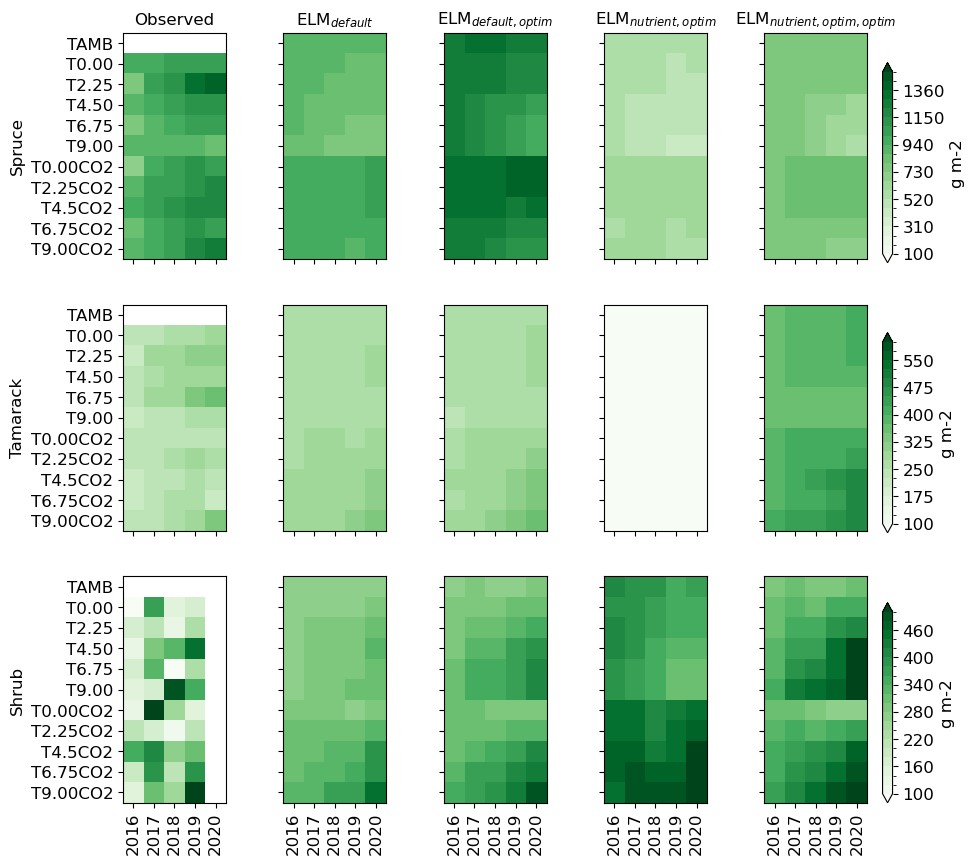

In [9]:
fig, axes = plt.subplots(3, 1+len(prefix_list), figsize = (10, 10), sharex = True, sharey = True)
for i, (pft,name) in enumerate(zip(['2','3','11'], ['Spruce','Tamarack','Shrub'])):
    if i == 0:
        norm = BoundaryNorm(boundaries=np.linspace(100, 1500, 21), ncolors=256, extend = 'both')
    elif i == 1:
        norm = BoundaryNorm(boundaries=np.linspace(100, 600, 21), ncolors=256, extend = 'both')
    else:        
        norm = BoundaryNorm(boundaries=np.linspace(100, 500, 21), ncolors=256, extend = 'both')

    ax = axes[i, 0]
    temp = annual_biomass.loc[2016:2020, pft]
    temp = temp.loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
    temp = temp.T
    cf = ax.imshow(temp, norm = norm, cmap = 'Greens')
    ax.set_xticks(range(len(year_list[:-2])))
    ax.set_xticklabels(year_list[1:-1], rotation = 90)
    ax.set_yticks(range(11))
    ax.set_yticklabels(xticklabels)
    if i == 0:
        ax.set_title('Observed')
    ax.set_ylabel(name)

    for j, (prefix,case) in enumerate(zip(prefix_list, name_list)):
        ax = axes[i,j+1]
        temp = collection_gs[prefix].loc[2016:2020, pft]
        temp = temp.loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp = temp.T
        cf = ax.imshow(temp, norm = norm, cmap = 'Greens')
        ax.set_xticks(range(len(year_list[:-2])))
        ax.set_xticklabels(year_list[1:-1], rotation = 90)
        ax.set_yticks(range(11))
        ax.set_yticklabels(xticklabels)
        if i == 0:
            ax.set_title(case)

    cax = fig.add_axes([0.9, 0.65 - 0.27 * i, 0.01, 0.2])
    plt.colorbar(cf, cax = cax, orientation = 'vertical', label = 'g m-2')